In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import OrdinalEncoder

In [1]:
pip install mlflow sqlalchemy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
data = pd.read_csv("PlayTennis.csv")
data

,Outlook,Temperature,Humidity,Wind,Play Tennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [3]:
from sklearn.preprocessing import OrdinalEncoder
feature_cols = ["Outlook", "Temperature", "Humidity", "Wind"]
target_col = "Play Tennis"

encoder = OrdinalEncoder()
data[feature_cols] = encoder.fit_transform(data[feature_cols])

# Encoding the target separately to keep class names accessible
play_encoder = OrdinalEncoder()
data[target_col] = play_encoder.fit_transform(data[[target_col]])

In [4]:
data

,Outlook,Temperature,Humidity,Wind,Play Tennis
0,2.0,1.0,0.0,1.0,0.0
1,2.0,1.0,0.0,0.0,0.0
2,0.0,1.0,0.0,1.0,1.0
3,1.0,2.0,0.0,1.0,1.0
4,1.0,0.0,1.0,1.0,1.0
5,1.0,0.0,1.0,0.0,0.0
6,0.0,0.0,1.0,0.0,1.0
7,2.0,2.0,0.0,1.0,0.0
8,2.0,0.0,1.0,1.0,1.0
9,1.0,2.0,1.0,1.0,1.0


In [5]:
x = data[feature_cols]
y = data[target_col]

In [6]:

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [7]:
# 4. Model 1: Gini Index
clf_gini = DecisionTreeClassifier(criterion="gini", random_state=42)
clf_gini.fit(x_train, y_train)
y_pred_gini = clf_gini.predict(x_test)

In [8]:
# 5. Model 2: Entropy
clf_entropy = DecisionTreeClassifier(criterion="entropy", max_depth=None, min_samples_split=2, random_state=42)
clf_entropy.fit(x_train, y_train)
y_pred_entropy = clf_entropy.predict(x_test)

In [9]:
print("Accuracy With Gini: ",accuracy_score(y_test, y_pred_gini))
print("Classification With Gini: ",classification_report(y_test, y_pred_gini))
print("Confusion Matrix With Gini: ",confusion_matrix(y_test, y_pred_gini))

# 6. Evaluation
print("--- Gini Index Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gini)}")
print(classification_report(y_test, y_pred_gini))
print("Confusion Matrix With Gini: ",confusion_matrix(y_test, y_pred_gini))


print("\n--- Entropy Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_entropy)}")
print(classification_report(y_test, y_pred_entropy))
print("Confusion Matrix With Entropy: ",confusion_matrix(y_test, y_pred_entropy))


Accuracy With Gini:  1.0
Classification With Gini:                precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         1
         1.0       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

Confusion Matrix With Gini:  [[1 0]
 [0 2]]
--- Gini Index Results ---
Accuracy: 1.0
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         1
         1.0       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

Confusion Matrix With Gini:  [[1 0]
 [0 2]]

--- Entropy Results ---
Accuracy: 1.0
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         1
         1.0     

In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy With entropy: ",accuracy_score(y_test, y_pred_entropy))
print("C",classification_report(y_test, y_pred_entropy))
print("Confusion Matrix With entropy:           ",confusion_matrix(y_test, y_pred_entropy))

Accuracy With entropy:  1.0
C               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         1
         1.0       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

Confusion Matrix With entropy:            [[1 0]
 [0 2]]


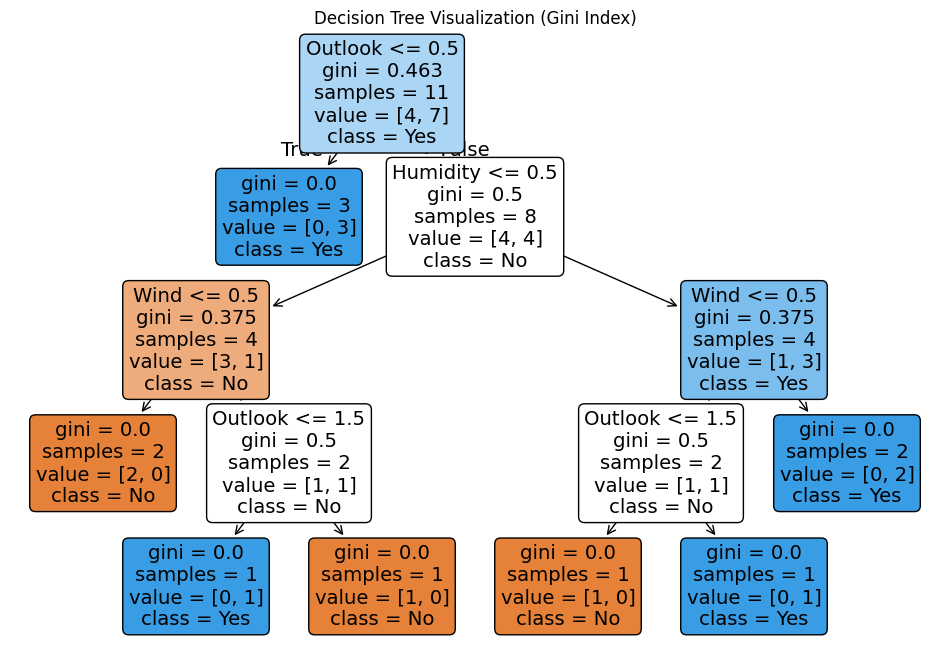

In [12]:
# 7. Visualization
plt.figure(figsize=(12,8))
plot_tree(clf_gini, 
          filled=True, 
          feature_names=feature_cols, 
          class_names=play_encoder.categories_[0].astype(str), 
          rounded=True)
plt.title("Decision Tree Visualization (Gini Index)")
plt.show()

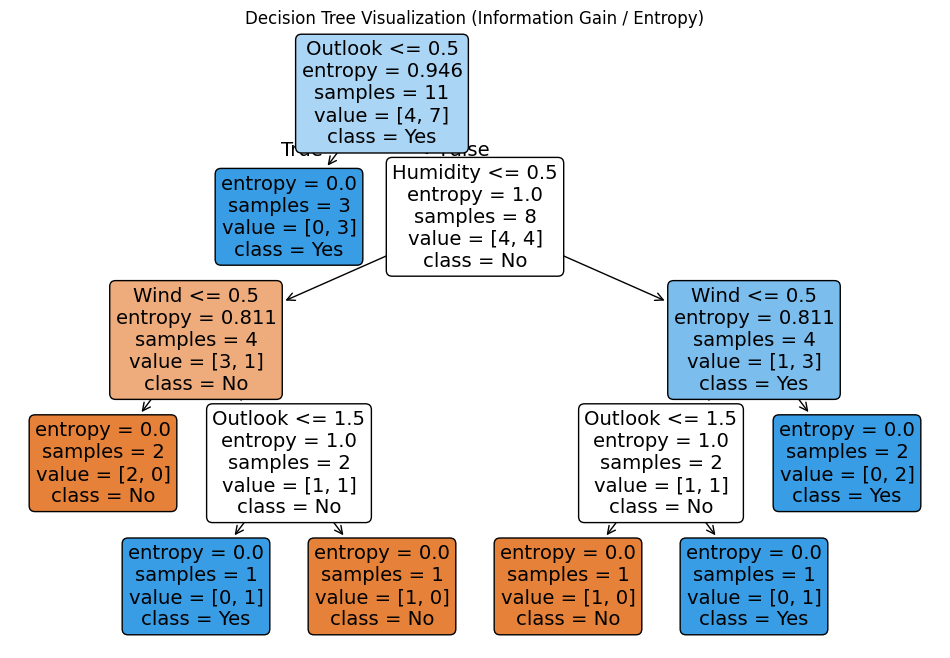

In [13]:
plt.figure(figsize=(12,8))
plot_tree(clf_entropy, 
          filled=True, 
          feature_names=feature_cols, 
          class_names=play_encoder.categories_[0].astype(str), 
          rounded=True)
plt.title("Decision Tree Visualization (Information Gain / Entropy)")
plt.show()